# CS-378: Design and Analysis of Algorithms
## Frequent Itemset Mining: Apriori vs ProbBF
### Comparison + Optimizations
**Datasets:** Chess, Connect, Mushroom  
**Modern Algorithm:** ProbBF (Sadeequllah et al., IEEE Access 2024)

## Cell 1: Install Dependencies

In [14]:
!pip install mlxtend pandas matplotlib psutil tabulate

## Cell 2: Imports

In [15]:
import time
import tracemalloc
import psutil
import os
import itertools
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

print('All imports successful!')

All imports successful!


## Cell 3: Load Dataset
> **Put your chess.dat, connect.dat, mushroom.dat files in the same folder as this notebook.**  
> Each line = one transaction, items are space-separated integers.

In [16]:
# The following code was moved into the experiment loop in 'Cell 8: Run All Experiments' (1qBYa87-m_3O)
# to ensure the Connect dataset is always reduced before running experiments.
# if 'Connect' in loaded and len(loaded['Connect']) > 15000:
#     print(f"Reducing 'Connect' dataset from {len(loaded['Connect'])} to 15,000 transactions.")
#     loaded['Connect'] = loaded['Connect'][:15000]
#     print(f"New 'Connect' size: {len(loaded['Connect'])} transactions.")
# else:
#     print("'Connect' dataset not found or already smaller than 15,000 transactions.")

In [17]:
def load_dataset(filepath):
    """Load a .dat file. Each line is a transaction of space-separated integers."""
    transactions = []
    with open(filepath, 'r') as f:
        for line in f:
            items = frozenset(map(int, line.strip().split()))
            if items:
                transactions.append(items)
    return transactions

# -----------------------------------------------
# CHANGE PATHS IF YOUR FILES ARE IN A SUBFOLDER
# e.g. 'data/chess.dat'
# -----------------------------------------------
DATASETS = {
    'Chess':    'chess.dat',
    'Connect':  'connect.dat',
    'Mushroom': 'mushroom.dat'
}

loaded = {}
for name, path in DATASETS.items():
    if os.path.exists(path):
        loaded[name] = load_dataset(path)
        print(f'{name}: {len(loaded[name])} transactions loaded')
    else:
        print(f'WARNING: {path} not found. Put the file next to this notebook.')

Chess: 3196 transactions loaded
Connect: 67557 transactions loaded
Mushroom: 8124 transactions loaded


### Action Required: Upload Datasets

It appears the dataset files (`chess.dat`, `connect.dat`, `mushroom.dat`) were not found in the Colab environment, causing the `df` DataFrame to be empty and subsequent analysis to fail.

**To fix this, please follow these steps:**

1.  **Locate the dataset files:** Make sure you have `chess.dat`, `connect.dat`, and `mushroom.dat` files on your local machine.
2.  **Upload to Colab:** In the left sidebar, click on the **'Files' icon** (folder icon).
3.  **Click 'Upload'**: Drag and drop your `.dat` files directly into the file browser, or click the 'Upload' icon and select the files.
    *   **Important:** Ensure the files are uploaded to the root directory of your Colab session, or specify the correct path in the `DATASETS` dictionary in 'Cell 3'.
4.  **Re-run cells:** After uploading, please re-run 'Cell 3: Load Dataset' and all subsequent cells ('Cell 4' through 'Cell 14') to load the data and regenerate the results.

## Cell 4: Baseline Apriori (Standard Implementation)

In [18]:
def apriori(transactions, min_sup_ratio):
    """
    Standard Apriori algorithm.
    - Horizontal data format
    - Full DB scan per level
    - Returns: (frequent_itemsets dict, candidates_generated count)
    """
    n = len(transactions)
    min_sup_count = int(min_sup_ratio * n)

    frequent_itemsets = {}  # itemset -> support_count
    total_candidates = 0

    # --- Pass 1: Find frequent 1-itemsets ---
    item_counts = defaultdict(int)
    for t in transactions:
        for item in t:
            item_counts[item] += 1

    F1 = {frozenset([item]): count
          for item, count in item_counts.items()
          if count >= min_sup_count}
    frequent_itemsets.update(F1)
    total_candidates += len(item_counts)

    prev_frequent = list(F1.keys())
    k = 2

    while prev_frequent:
        # --- Candidate Generation (join step) ---
        candidates = set()
        prev_list = [list(s) for s in prev_frequent]
        for i in range(len(prev_list)):
            for j in range(i + 1, len(prev_list)):
                union = frozenset(prev_list[i]) | frozenset(prev_list[j])
                if len(union) == k:
                    candidates.add(union)

        # --- Apriori Pruning ---
        pruned = set()
        for c in candidates:
            subsets_ok = True
            for item in c:
                subset = c - frozenset([item])
                if subset not in frequent_itemsets:
                    subsets_ok = False
                    break
            if subsets_ok:
                pruned.add(c)

        total_candidates += len(pruned)

        # --- Support Counting (full DB scan) ---
        candidate_counts = defaultdict(int)
        for t in transactions:
            for c in pruned:
                if c.issubset(t):
                    candidate_counts[c] += 1

        Fk = {c: count for c, count in candidate_counts.items()
              if count >= min_sup_count}
        frequent_itemsets.update(Fk)
        prev_frequent = list(Fk.keys())
        k += 1

    return frequent_itemsets, total_candidates

print('Apriori defined.')

Apriori defined.


## Cell 5: Optimization 1 — Apriori with Vertical TID-lists
> Instead of scanning the full database each pass, we store transaction ID sets per item and use set intersection for support counting. Dramatically faster on dense data.

In [19]:
def apriori_vertical(transactions, min_sup_ratio):
    """
    Optimized Apriori using vertical TID-list format.
    Support count = |intersection of TID sets|
    No full DB scan after pass 1.
    """
    n = len(transactions)
    min_sup_count = int(min_sup_ratio * n)

    frequent_itemsets = {}
    total_candidates = 0

    # --- Build vertical TID-list for each item ---
    tid_lists = defaultdict(set)
    for tid, t in enumerate(transactions):
        for item in t:
            tid_lists[item].add(tid)

    # --- Pass 1: Frequent 1-itemsets ---
    F1_tids = {}
    for item, tids in tid_lists.items():
        total_candidates += 1
        if len(tids) >= min_sup_count:
            F1_tids[frozenset([item])] = tids
            frequent_itemsets[frozenset([item])] = len(tids)

    prev_freq_tids = F1_tids
    k = 2

    while prev_freq_tids:
        new_freq_tids = {}
        prev_list = list(prev_freq_tids.keys())

        for i in range(len(prev_list)):
            for j in range(i + 1, len(prev_list)):
                union = prev_list[i] | prev_list[j]
                if len(union) != k:
                    continue
                total_candidates += 1

                # Apriori pruning
                valid = True
                for item in union:
                    subset = union - frozenset([item])
                    if subset not in frequent_itemsets:
                        valid = False
                        break
                if not valid:
                    continue

                # Support via TID intersection (no DB scan!)
                tids = prev_freq_tids[prev_list[i]] & prev_freq_tids[prev_list[j]]
                if len(tids) >= min_sup_count:
                    new_freq_tids[union] = tids
                    frequent_itemsets[union] = len(tids)

        prev_freq_tids = new_freq_tids
        k += 1

    return frequent_itemsets, total_candidates

print('Vertical TID Apriori defined.')

Vertical TID Apriori defined.


## Cell 6: ProbBF Algorithm (Sadeequllah et al., 2024)
> Uses probabilistic support prediction (PSPM) for itemsets of size ≥ 3. No DB scan after pass 2.

In [20]:
def probBF(transactions, min_sup_ratio):
    """
    ProbBF Algorithm — Probabilistic Frequent Itemset Mining.

    Key idea:
    - Pass 1: Find frequent 1-itemsets using TID lists
    - Pass 2: Find frequent 2-itemsets using TID intersection
    - Pass 3+: Use PSPM formula to PREDICT support (no DB scan)

    PSPM formula for 3-itemset {A,B,C}:
        support(ABC) = (|AB| * |AC| * |BC| * |U|) / (|A| * |B| * |C|)

    With upper/lower bound clipping (Eq. 11-13 from paper).
    """
    n = len(transactions)
    min_sup_count = int(min_sup_ratio * n)

    frequent_itemsets = {}  # frozenset -> support_count (float for predicted)

    # --- Pass 1: TID lists for 1-itemsets ---
    tid_lists = defaultdict(set)
    for tid, t in enumerate(transactions):
        for item in t:
            tid_lists[item].add(tid)

    F1_tids = {}
    for item, tids in tid_lists.items():
        if len(tids) >= min_sup_count:
            key = frozenset([item])
            F1_tids[key] = tids
            frequent_itemsets[key] = len(tids)

    freq_items = sorted(F1_tids.keys(), key=lambda x: frequent_itemsets[x], reverse=True)

    # --- Pass 2: TID intersection for 2-itemsets ---
    F2_tids = {}
    for i in range(len(freq_items)):
        for j in range(i + 1, len(freq_items)):
            pair = freq_items[i] | freq_items[j]
            tids = F1_tids[freq_items[i]] & F1_tids[freq_items[j]]
            if len(tids) >= min_sup_count:
                F2_tids[pair] = tids
                frequent_itemsets[pair] = len(tids)

    # Free TID memory (simulating ProbBF's memory efficiency)
    del tid_lists

    # --- Pass 3+: Probabilistic support prediction (PSPM) ---
    def pspm_3(A, B, C):
        """
        PSPM for 3-itemset {A, B, C}.
        Uses Equation 8 from the paper.
        """
        sA  = frequent_itemsets.get(frozenset(A), 0)
        sB  = frequent_itemsets.get(frozenset(B), 0)
        sC  = frequent_itemsets.get(frozenset(C), 0)
        sAB = frequent_itemsets.get(frozenset(A) | frozenset(B), 0)
        sAC = frequent_itemsets.get(frozenset(A) | frozenset(C), 0)
        sBC = frequent_itemsets.get(frozenset(B) | frozenset(C), 0)

        if sA == 0 or sB == 0 or sC == 0:
            return 0

        predicted = (sAB * sAC * sBC * n) / (sA * sB * sC)

        # Bound clipping (Eq. 11-13)
        upper = min(sAB, sAC, sBC)
        lower = max(sAB + sAC - sA, sAB + sBC - sB, sAC + sBC - sC, 0)
        predicted = min(predicted, upper)
        predicted = max(predicted, lower)

        return predicted

    def pspm_k(pref_items, A, B, C):
        """
        PSPM for k-itemset (k >= 4).
        Uses Equation 9 from the paper.
        pref_items: frozenset of prefix items
        A, B, C: the last 3 items (as single-item frozensets)
        """
        pref = frozenset(pref_items)
        sP   = frequent_itemsets.get(pref, n)  # support of prefix
        sPAB = frequent_itemsets.get(pref | A | B, 0)
        sPAC = frequent_itemsets.get(pref | A | C, 0)
        sPBC = frequent_itemsets.get(pref | B | C, 0)
        sPA  = frequent_itemsets.get(pref | A, 0)
        sPB  = frequent_itemsets.get(pref | B, 0)
        sPC  = frequent_itemsets.get(pref | C, 0)

        if sPA == 0 or sPB == 0 or sPC == 0 or sP == 0:
            return 0

        predicted = (sPAB * sPAC * sPBC * sP) / (sPA * sPB * sPC)

        # Bound clipping
        upper = min(sPAB, sPAC, sPBC)
        lower = max(sPAB + sPAC - sPA,
                    sPAB + sPBC - sPB,
                    sPAC + sPBC - sPC, 0)
        predicted = min(predicted, upper)
        predicted = max(predicted, lower)

        return predicted

    # Build 3-itemsets from frequent 2-itemsets
    freq_2_list = list(F2_tids.keys())
    freq_1_items = [list(k)[0] for k in freq_items]

    # Generate candidate 3-itemsets
    F3 = {}
    for pair in freq_2_list:
        pair_list = list(pair)
        for item_key in freq_items:
            item = list(item_key)[0]
            if item in pair:
                continue
            triple = pair | frozenset([item])
            if triple in frequent_itemsets:
                continue
            # Check all 2-subsets are frequent
            items_list = list(triple)
            subsets_ok = all(
                frozenset([items_list[i], items_list[j]]) in frequent_itemsets
                for i in range(3) for j in range(i+1, 3)
            )
            if not subsets_ok:
                continue
            items_sorted = sorted(items_list)
            A = frozenset([items_sorted[0]])
            B = frozenset([items_sorted[1]])
            C = frozenset([items_sorted[2]])
            pred_sup = pspm_3(A, B, C)
            if pred_sup >= min_sup_count:
                F3[triple] = pred_sup
                frequent_itemsets[triple] = pred_sup

    # Generate 4+ itemsets
    prev_freq = F3
    k = 4
    MAX_K = 8  # cap to avoid infinite loops on very dense data

    while prev_freq and k <= MAX_K:
        new_freq = {}
        prev_list = list(prev_freq.keys())
        for i in range(len(prev_list)):
            for j in range(i + 1, len(prev_list)):
                union = prev_list[i] | prev_list[j]
                if len(union) != k or union in frequent_itemsets:
                    continue
                items_sorted = sorted(list(union))
                pref = frozenset(items_sorted[:-3])
                A = frozenset([items_sorted[-3]])
                B = frozenset([items_sorted[-2]])
                C = frozenset([items_sorted[-1]])
                pred_sup = pspm_k(pref, A, B, C)
                if pred_sup >= min_sup_count:
                    new_freq[union] = pred_sup
                    frequent_itemsets[union] = pred_sup
        prev_freq = new_freq
        k += 1

    return frequent_itemsets

print('ProbBF defined.')

ProbBF defined.


## Cell 7: Measurement Utility

In [21]:
def measure(func, *args):
    """Run a function and measure wall time + peak memory."""
    tracemalloc.start()
    t0 = time.perf_counter()
    result = func(*args)
    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    elapsed = round(t1 - t0, 4)
    peak_mb = round(peak / 1024 / 1024, 2)
    return result, elapsed, peak_mb

print('Measurement utility ready.')

Measurement utility ready.


## Cell 8: Run All Experiments
> This runs all 3 algorithms on all loaded datasets at 4 support thresholds.  
> **Warning: Connect is large. If it's too slow, reduce MIN_SUPS to [0.7, 0.8]**

In [22]:
# Experiments refactored into individual cells per dataset below.

## Cell 8.1: Initialize Experiment Parameters and Reduce Connect Data

In [24]:
results = []
TIME_LIMIT = 60 # seconds; stop running algorithm if it exceeds this (e.g., if Apriori is too slow)

# Reduce 'Connect' dataset if it's too large, as mentioned in 'Cell 3'
if 'Connect' in loaded and len(loaded['Connect']) > 15000:
    print(f"Reducing 'Connect' dataset from {len(loaded['Connect'])} to 15,000 transactions.")
    loaded['Connect'] = loaded['Connect'][:15000]
    print(f"New 'Connect' size: {len(loaded['Connect'])} transactions.")
else:
    print("'Connect' dataset not found or already smaller than 15,000 transactions.")

print('Experiment parameters initialized.')

Reducing 'Connect' dataset from 67557 to 15,000 transactions.
New 'Connect' size: 15000 transactions.
Experiment parameters initialized.


## Cell 8.4: Run Experiments for Mushroom Dataset

## Cell 8.2: Run Experiments for Chess Dataset

In [25]:
ds_name = 'Chess'
transactions = loaded.get(ds_name)

# Define MIN_SUPS specifically for Chess
MIN_SUPS_CHESS = [0.95, 0.90, 0.85] # Example values, adjust as needed

if transactions is None:
    print(f'WARNING: {ds_name} dataset not found, skipping experiments.')
else:
    print(f'\n===== {ds_name} ({len(transactions)} transactions) =====')

    skip_rest_of_sups = False

    for sup in MIN_SUPS_CHESS:
        if skip_rest_of_sups:
            print(f'  min_sup = {int(sup*100)}% -> SKIPPED (Previous level too slow)')
            continue

        print(f'  min_sup = {int(sup*100)}%')
        row = {'Dataset': ds_name, 'min_sup': sup, 'Transactions': len(transactions)}

        # --- 1. Baseline Apriori ---
        try:
            (fi, cands), t, mem = measure(apriori, transactions, sup)
            row['Apriori_time'] = t
            row['Apriori_mem']  = mem
            row['Apriori_fi']   = len(fi)
            row['Apriori_cands']= cands
            print(f'    Apriori:          {t:.2f}s | {mem} MB | {len(fi)} FI | {cands} candidates')

            # CRITICAL OBSERVATION: If Apriori is taking too long,
            # lower supports will likely crash or hang your system.
            if t > TIME_LIMIT:
                print(f"    [!] Warning: Execution time ({t:.2f}s) exceeded limit. Skipping lower supports for {ds_name}.")
                skip_rest_of_sups = True

        except Exception as e:
            print(f'    Apriori FAILED: {e}')
            row['Apriori_time'] = row['Apriori_mem'] = row['Apriori_fi'] = row['Apriori_cands'] = None

        # --- 2. Optimized Apriori (Vertical TID) ---
        try:
            (fi_v, cands_v), t_v, mem_v = measure(apriori_vertical, transactions, sup)
            row['VertApriori_time'] = t_v
            row['VertApriori_mem']  = mem_v
            row['VertApriori_fi']   = len(fi_v)
            row['VertApriori_cands']= cands_v

            # Use 1.0 as fallback to avoid division by zero
            base_t = row.get('Apriori_time') if row.get('Apriori_time') else t_v
            speedup = round(base_t / t_v, 2) if t_v > 0 else 'N/A'
            print(f'    Vert Apriori:     {t_v:.2f}s | {mem_v} MB | {len(fi_v)} FI | Speedup: {speedup}x')
        except Exception as e:
            print(f'    Vert Apriori FAILED: {e}')
            row['VertApriori_time'] = row['VertApriori_mem'] = row['VertApriori_fi'] = row['VertApriori_cands'] = None

        # --- 3. ProbBF ---
        try:
            fi_p, t_p, mem_p = measure(probBF, transactions, sup)
            row['ProbBF_time'] = t_p
            row['ProbBF_mem']  = mem_p
            row['ProbBF_fi']   = len(fi_p)

            base_t = row.get('Apriori_time') if row.get('Apriori_time') else t_p
            speedup_p = round(base_t / t_p, 2) if t_p > 0 else 'N/A'
            print(f'    ProbBF:           {t_p:.2f}s | {mem_p} MB | {len(fi_p)} FI | Speedup: {speedup_p}x')
        except Exception as e:
            print(f'    ProbBF FAILED: {e}')
            row['ProbBF_time'] = row['ProbBF_mem'] = row['ProbBF_fi'] = None

        results.append(row)


===== Chess (3196 transactions) =====
  min_sup = 95%
    Apriori:          0.80s | 0.06 MB | 78 FI | 162 candidates
    Vert Apriori:     0.05s | 12.64 MB | 78 FI | Speedup: 16.75x
    ProbBF:           0.04s | 9.25 MB | 78 FI | Speedup: 20.5x
  min_sup = 90%
    Apriori:          6.71s | 0.64 MB | 628 FI | 754 candidates
    Vert Apriori:     0.69s | 53.13 MB | 628 FI | Speedup: 9.67x
    ProbBF:           0.57s | 14.65 MB | 639 FI | Speedup: 11.78x
  min_sup = 85%
    Apriori:          33.51s | 2.66 MB | 2690 FI | 2913 candidates
    Vert Apriori:     8.28s | 192.95 MB | 2690 FI | Speedup: 4.04x
    ProbBF:           9.80s | 19.29 MB | 2719 FI | Speedup: 3.42x


## Cell 8.3: Run Experiments for Connect Dataset

In [37]:
ds_name = 'Connect'
transactions = loaded.get(ds_name)

# Define MIN_SUPS specifically for Connect
MIN_SUPS_CONNECT = [0.99, 0.98, 0.97] # Example values, adjust as needed

if transactions is None:
    print(f'WARNING: {ds_name} dataset not found, skipping experiments.')
else:
    print(f'\n===== {ds_name} ({len(transactions)} transactions) =====')

    skip_rest_of_sups = False

    for sup in MIN_SUPS_CONNECT:
        if skip_rest_of_sups:
            print(f'  min_sup = {int(sup*100)}% -> SKIPPED (Previous level too slow)')
            continue

        print(f'  min_sup = {int(sup*100)}%')
        row = {'Dataset': ds_name, 'min_sup': sup, 'Transactions': len(transactions)}

        # --- 1. Baseline Apriori ---
        try:
            (fi, cands), t, mem = measure(apriori, transactions, sup)
            row['Apriori_time'] = t
            row['Apriori_mem']  = mem
            row['Apriori_fi']   = len(fi)
            row['Apriori_cands']= cands
            print(f'    Apriori:          {t:.2f}s | {mem} MB | {len(fi)} FI | {cands} candidates')

            # CRITICAL OBSERVATION: If Apriori is taking too long,
            # lower supports will likely crash or hang your system.
            if t > TIME_LIMIT:
                print(f"    [!] Warning: Execution time ({t:.2f}s) exceeded limit. Skipping lower supports for {ds_name}.")
                skip_rest_of_sups = True

        except Exception as e:
            print(f'    Apriori FAILED: {e}')
            row['Apriori_time'] = row['Apriori_mem'] = row['Apriori_fi'] = row['Apriori_cands'] = None

        # --- 2. Optimized Apriori (Vertical TID) ---
        try:
            (fi_v, cands_v), t_v, mem_v = measure(apriori_vertical, transactions, sup)
            row['VertApriori_time'] = t_v
            row['VertApriori_mem']  = mem_v
            row['VertApriori_fi']   = len(fi_v)
            row['VertApriori_cands']= cands_v

            # Use 1.0 as fallback to avoid division by zero
            base_t = row.get('Apriori_time') if row.get('Apriori_time') else t_v
            speedup = round(base_t / t_v, 2) if t_v > 0 else 'N/A'
            print(f'    Vert Apriori:     {t_v:.2f}s | {mem_v} MB | {len(fi_v)} FI | Speedup: {speedup}x')
        except Exception as e:
            print(f'    Vert Apriori FAILED: {e}')
            row['VertApriori_time'] = row['VertApriori_mem'] = row['VertApriori_fi'] = row['VertApriori_cands'] = None

        # --- 3. ProbBF ---
        try:
            fi_p, t_p, mem_p = measure(probBF, transactions, sup)
            row['ProbBF_time'] = t_p
            row['ProbBF_mem']  = mem_p
            row['ProbBF_fi']   = len(fi_p)

            base_t = row.get('Apriori_time') if row.get('Apriori_time') else t_p
            speedup_p = round(base_t / t_p, 2) if t_p > 0 else 'N/A'
            print(f'    ProbBF:           {t_p:.2f}s | {mem_p} MB | {len(fi_p)} FI | Speedup: {speedup_p}x')
        except Exception as e:
            print(f'    ProbBF FAILED: {e}')
            row['ProbBF_time'] = row['ProbBF_mem'] = row['ProbBF_fi'] = None

        results.append(row)


===== Connect (15000 transactions) =====
  min_sup = 99%
    Apriori:          103.92s | 1.74 MB | 2223 FI | 2343 candidates
    [!] Warning: Execution time (103.92s) exceeded limit. Skipping lower supports for Connect.
    Vert Apriori:     14.29s | 576.06 MB | 2223 FI | Speedup: 7.27x
    ProbBF:           5.93s | 60.2 MB | 2204 FI | Speedup: 17.52x
  min_sup = 98% -> SKIPPED (Previous level too slow)
  min_sup = 97% -> SKIPPED (Previous level too slow)


## Cell 8.4: Run Experiments for Mushroom Dataset

In [26]:
ds_name = 'Mushroom'
transactions = loaded.get(ds_name)

# Define MIN_SUPS specifically for Mushroom
MIN_SUPS_MUSHROOM = [0.90, 0.85, 0.80] # Example values, adjust as needed

if transactions is None:
    print(f'WARNING: {ds_name} dataset not found, skipping experiments.')
else:
    print(f'\n===== {ds_name} ({len(transactions)} transactions) =====')

    skip_rest_of_sups = False

    for sup in MIN_SUPS_MUSHROOM:
        if skip_rest_of_sups:
            print(f'  min_sup = {int(sup*100)}% -> SKIPPED (Previous level too slow)')
            continue

        print(f'  min_sup = {int(sup*100)}%')
        row = {'Dataset': ds_name, 'min_sup': sup, 'Transactions': len(transactions)}

        # --- 1. Baseline Apriori ---
        try:
            (fi, cands), t, mem = measure(apriori, transactions, sup)
            row['Apriori_time'] = t
            row['Apriori_mem']  = mem
            row['Apriori_fi']   = len(fi)
            row['Apriori_cands']= cands
            print(f'    Apriori:          {t:.2f}s | {mem} MB | {len(fi)} FI | {cands} candidates')

            # CRITICAL OBSERVATION: If Apriori is taking too long,
            # lower supports will likely crash or hang your system.
            if t > TIME_LIMIT:
                print(f"    [!] Warning: Execution time ({t:.2f}s) exceeded limit. Skipping lower supports for {ds_name}.")
                skip_rest_of_sups = True

        except Exception as e:
            print(f'    Apriori FAILED: {e}')
            row['Apriori_time'] = row['Apriori_mem'] = row['Apriori_fi'] = row['Apriori_cands'] = None

        # --- 2. Optimized Apriori (Vertical TID) ---
        try:
            (fi_v, cands_v), t_v, mem_v = measure(apriori_vertical, transactions, sup)
            row['VertApriori_time'] = t_v
            row['VertApriori_mem']  = mem_v
            row['VertApriori_fi']   = len(fi_v)
            row['VertApriori_cands']= cands_v

            # Use 1.0 as fallback to avoid division by zero
            base_t = row.get('Apriori_time') if row.get('Apriori_time') else t_v
            speedup = round(base_t / t_v, 2) if t_v > 0 else 'N/A'
            print(f'    Vert Apriori:     {t_v:.2f}s | {mem_v} MB | {len(fi_v)} FI | Speedup: {speedup}x')
        except Exception as e:
            print(f'    Vert Apriori FAILED: {e}')
            row['VertApriori_time'] = row['VertApriori_mem'] = row['VertApriori_fi'] = row['VertApriori_cands'] = None

        # --- 3. ProbBF ---
        try:
            fi_p, t_p, mem_p = measure(probBF, transactions, sup)
            row['ProbBF_time'] = t_p
            row['ProbBF_mem']  = mem_p
            row['ProbBF_fi']   = len(fi_p)

            base_t = row.get('Apriori_time') if row.get('Apriori_time') else t_p
            speedup_p = round(base_t / t_p, 2) if t_p > 0 else 'N/A'
            print(f'    ProbBF:           {t_p:.2f}s | {mem_p} MB | {len(fi_p)} FI | Speedup: {speedup_p}x')
        except Exception as e:
            print(f'    ProbBF FAILED: {e}')
            row['ProbBF_time'] = row['ProbBF_mem'] = row['ProbBF_fi'] = None

        results.append(row)


===== Mushroom (8124 transactions) =====
  min_sup = 90%
    Apriori:          0.37s | 0.02 MB | 9 FI | 126 candidates
    Vert Apriori:     0.04s | 13.51 MB | 9 FI | Speedup: 9.35x
    ProbBF:           0.04s | 13.5 MB | 9 FI | Speedup: 9.21x
  min_sup = 85%
    Apriori:          0.44s | 0.02 MB | 15 FI | 130 candidates
    Vert Apriori:     0.05s | 16.01 MB | 15 FI | Speedup: 9.25x
    ProbBF:           0.04s | 13.51 MB | 15 FI | Speedup: 11.51x
  min_sup = 80%
    Apriori:          0.59s | 0.02 MB | 23 FI | 138 candidates
    Vert Apriori:     0.05s | 19.01 MB | 23 FI | Speedup: 12.41x
    ProbBF:           0.04s | 15.51 MB | 23 FI | Speedup: 14.9x


## Cell 8.5: Finalize Results DataFrame

In [38]:
df = pd.DataFrame(results)
print('\n\nDone! All experiment results stored in df')



Done! All experiment results stored in df


## Cell 9: Results Table

In [39]:
print(df.get('Apriori_time'))

0      0.7954
1      6.7106
2     33.5057
3      0.3731
4      0.4430
5      0.5857
6    103.9162
Name: Apriori_time, dtype: float64


In [40]:
# 1. Safely clean column names by forcing them to strings first
df.columns = [str(col).strip() for col in df.columns]

# 2. Check if the required columns exist before doing math
required_time_cols = ['Apriori_time', 'VertApriori_time', 'ProbBF_time']
missing_cols = [col for col in required_time_cols if col not in df.columns]

if not missing_cols:
    # Compute speedup columns if all time columns are present
    df['Speedup_Vert'] = (df['Apriori_time'] / df['VertApriori_time']).round(2)
    df['Speedup_ProbBF'] = (df['Apriori_time'] / df['ProbBF_time']).round(2)
else:
    print(f"Warning: Cannot calculate speedups. Missing columns: {missing_cols}")
    print(f"Available columns are: {df.columns.tolist()}")

# 3. Define your ideal display columns
display_cols = [
    'Dataset', 'min_sup',
    'Apriori_time', 'VertApriori_time', 'ProbBF_time',
    'Apriori_mem',  'VertApriori_mem',  'ProbBF_mem',
    'Apriori_fi',   'VertApriori_fi',   'ProbBF_fi',
    'Apriori_cands','VertApriori_cands',
    'Speedup_Vert', 'Speedup_ProbBF'
]

# 4. Safely filter out any columns that still might be missing
actual_display_cols = [col for col in display_cols if col in df.columns]

# 5. Display the final dataframe
display(df[actual_display_cols].fillna('N/A'))

,Dataset,min_sup,Apriori_time,VertApriori_time,ProbBF_time,Apriori_mem,VertApriori_mem,ProbBF_mem,Apriori_fi,VertApriori_fi,ProbBF_fi,Apriori_cands,VertApriori_cands,Speedup_Vert,Speedup_ProbBF
0,Chess,0.95,0.7954,0.0475,0.0388,0.06,12.64,9.25,78,78,78,162,423,16.75,20.50
1,Chess,0.90,6.7106,0.6937,0.5698,0.64,53.13,14.65,628,628,639,754,6056,9.67,11.78
2,Chess,0.85,33.5057,8.2837,9.8002,2.66,192.95,19.29,2690,2690,2719,2913,38274,4.04,3.42
3,Mushroom,0.90,0.3731,0.0399,0.0405,0.02,13.51,13.50,9,9,9,126,130,9.35,9.21
4,Mushroom,0.85,0.4430,0.0479,0.0385,0.02,16.01,13.51,15,15,15,130,143,9.25,11.51
5,Mushroom,0.80,0.5857,0.0472,0.0393,0.02,19.01,15.51,23,23,23,138,169,12.41,14.90
6,Connect,0.99,103.9162,14.2935,5.9326,1.74,576.06,60.20,2223,2223,2204,2343,30018,7.27,17.52


In [41]:
required_time_cols = ['Apriori_time', 'VertApriori_time', 'ProbBF_time']

# Check if the DataFrame is empty or if necessary columns are missing
if df.empty or any(col not in df.columns for col in required_time_cols):
    print("Warning: DataFrame is empty or required columns for speedup calculation are missing.")
    print("Please ensure datasets are loaded and experiments in Cell 8 are run successfully.")
    # Display the current (likely empty) DataFrame for inspection
    display(df)
else:
    # Compute speedup columns only if all required columns are present
    df['Speedup_Vert'] = (df['Apriori_time'] / df['VertApriori_time']).round(2)
    df['Speedup_ProbBF'] = (df['Apriori_time'] / df['ProbBF_time']).round(2)

    display_cols = [
        'Dataset', 'min_sup',
        'Apriori_time', 'VertApriori_time', 'ProbBF_time',
        'Apriori_mem',  'VertApriori_mem',  'ProbBF_mem',
        'Apriori_fi',   'VertApriori_fi',   'ProbBF_fi',
        'Apriori_cands','VertApriori_cands',
        'Speedup_Vert', 'Speedup_ProbBF'
    ]

    # Safely filter out any columns that might be missing from display_cols if df.columns changed for some reason
    actual_display_cols = [col for col in display_cols if col in df.columns]
    display(df[actual_display_cols].fillna('N/A'))

,Dataset,min_sup,Apriori_time,VertApriori_time,ProbBF_time,Apriori_mem,VertApriori_mem,ProbBF_mem,Apriori_fi,VertApriori_fi,ProbBF_fi,Apriori_cands,VertApriori_cands,Speedup_Vert,Speedup_ProbBF
0,Chess,0.95,0.7954,0.0475,0.0388,0.06,12.64,9.25,78,78,78,162,423,16.75,20.50
1,Chess,0.90,6.7106,0.6937,0.5698,0.64,53.13,14.65,628,628,639,754,6056,9.67,11.78
2,Chess,0.85,33.5057,8.2837,9.8002,2.66,192.95,19.29,2690,2690,2719,2913,38274,4.04,3.42
3,Mushroom,0.90,0.3731,0.0399,0.0405,0.02,13.51,13.50,9,9,9,126,130,9.35,9.21
4,Mushroom,0.85,0.4430,0.0479,0.0385,0.02,16.01,13.51,15,15,15,130,143,9.25,11.51
5,Mushroom,0.80,0.5857,0.0472,0.0393,0.02,19.01,15.51,23,23,23,138,169,12.41,14.90
6,Connect,0.99,103.9162,14.2935,5.9326,1.74,576.06,60.20,2223,2223,2204,2343,30018,7.27,17.52


## Cell 10: Plot — Runtime Comparison

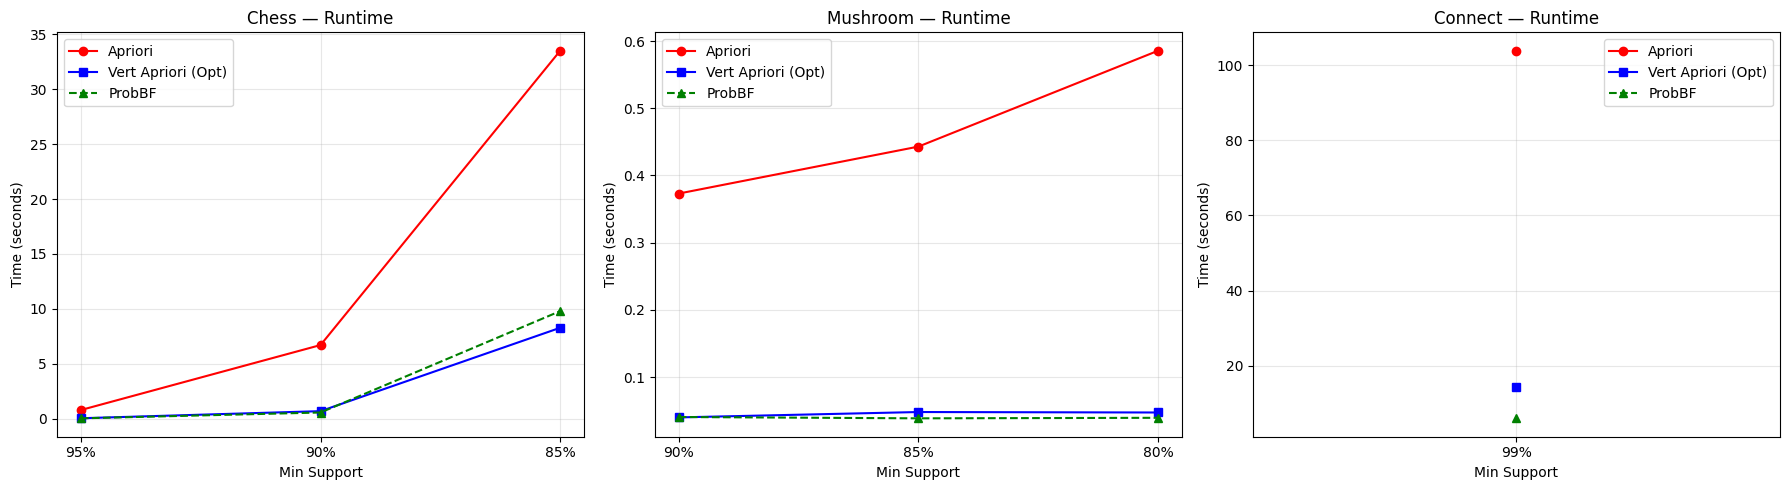

Saved: runtime_comparison.png


In [42]:
datasets = df['Dataset'].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df['Dataset'] == ds].copy()
    x = [f"{int(s*100)}%" for s in sub['min_sup']]
    ax.plot(x, sub['Apriori_time'],     marker='o', label='Apriori', color='red')
    ax.plot(x, sub['VertApriori_time'], marker='s', label='Vert Apriori (Opt)', color='blue')
    ax.plot(x, sub['ProbBF_time'],      marker='^', label='ProbBF', color='green', linestyle='--')
    ax.set_title(f'{ds} — Runtime')
    ax.set_xlabel('Min Support')
    ax.set_ylabel('Time (seconds)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('runtime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: runtime_comparison.png')

## Cell 11: Plot — Memory Comparison

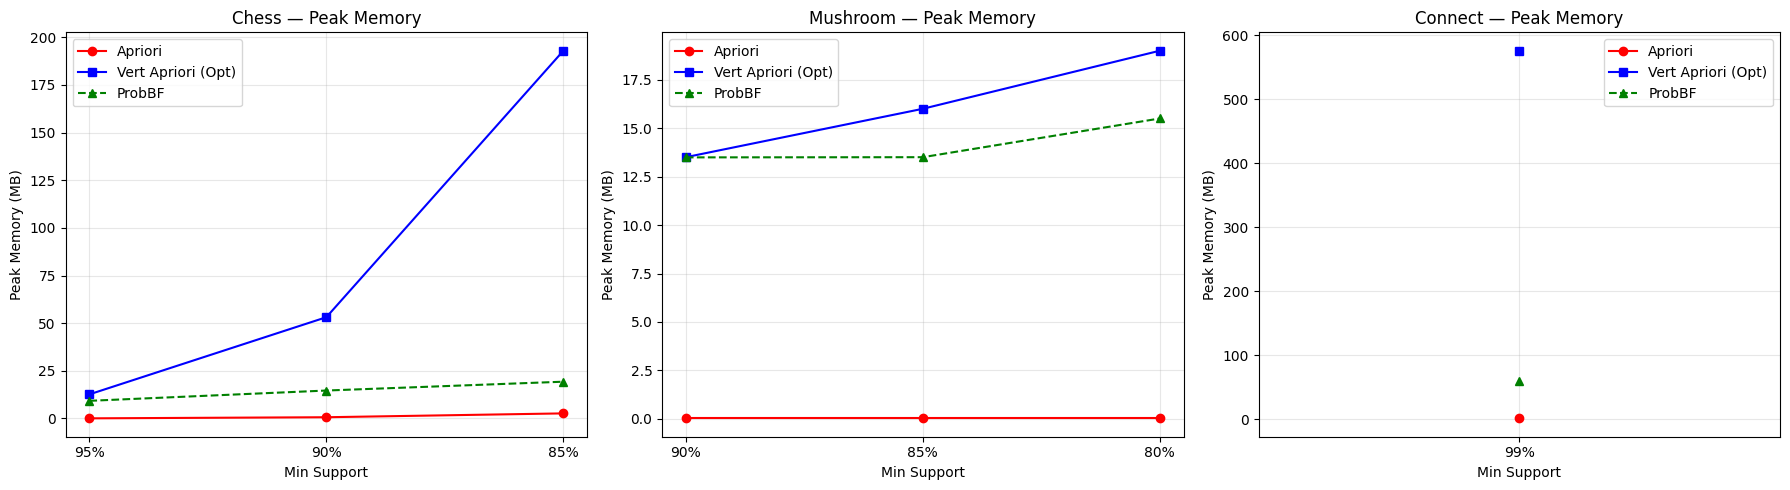

Saved: memory_comparison.png


In [43]:
fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df['Dataset'] == ds].copy()
    x = [f"{int(s*100)}%" for s in sub['min_sup']]
    ax.plot(x, sub['Apriori_mem'],     marker='o', label='Apriori', color='red')
    ax.plot(x, sub['VertApriori_mem'], marker='s', label='Vert Apriori (Opt)', color='blue')
    ax.plot(x, sub['ProbBF_mem'],      marker='^', label='ProbBF', color='green', linestyle='--')
    ax.set_title(f'{ds} — Peak Memory')
    ax.set_xlabel('Min Support')
    ax.set_ylabel('Peak Memory (MB)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('memory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: memory_comparison.png')

## Cell 12: Plot — Frequent Itemsets Found

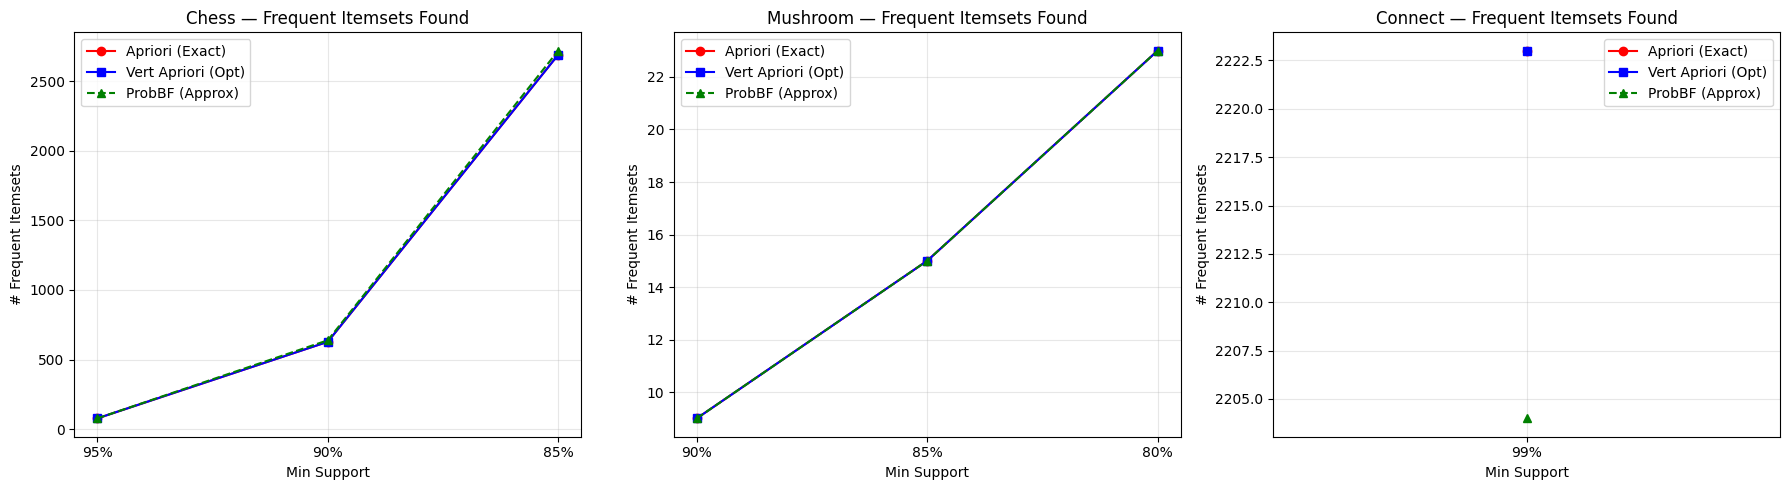

Saved: fi_comparison.png


In [44]:
fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df['Dataset'] == ds].copy()
    x = [f"{int(s*100)}%" for s in sub['min_sup']]
    ax.plot(x, sub['Apriori_fi'],     marker='o', label='Apriori (Exact)', color='red')
    ax.plot(x, sub['VertApriori_fi'], marker='s', label='Vert Apriori (Opt)', color='blue')
    ax.plot(x, sub['ProbBF_fi'],      marker='^', label='ProbBF (Approx)', color='green', linestyle='--')
    ax.set_title(f'{ds} — Frequent Itemsets Found')
    ax.set_xlabel('Min Support')
    ax.set_ylabel('# Frequent Itemsets')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fi_comparison.png')

## Cell 13: Plot — Speedup of Optimizations over Baseline

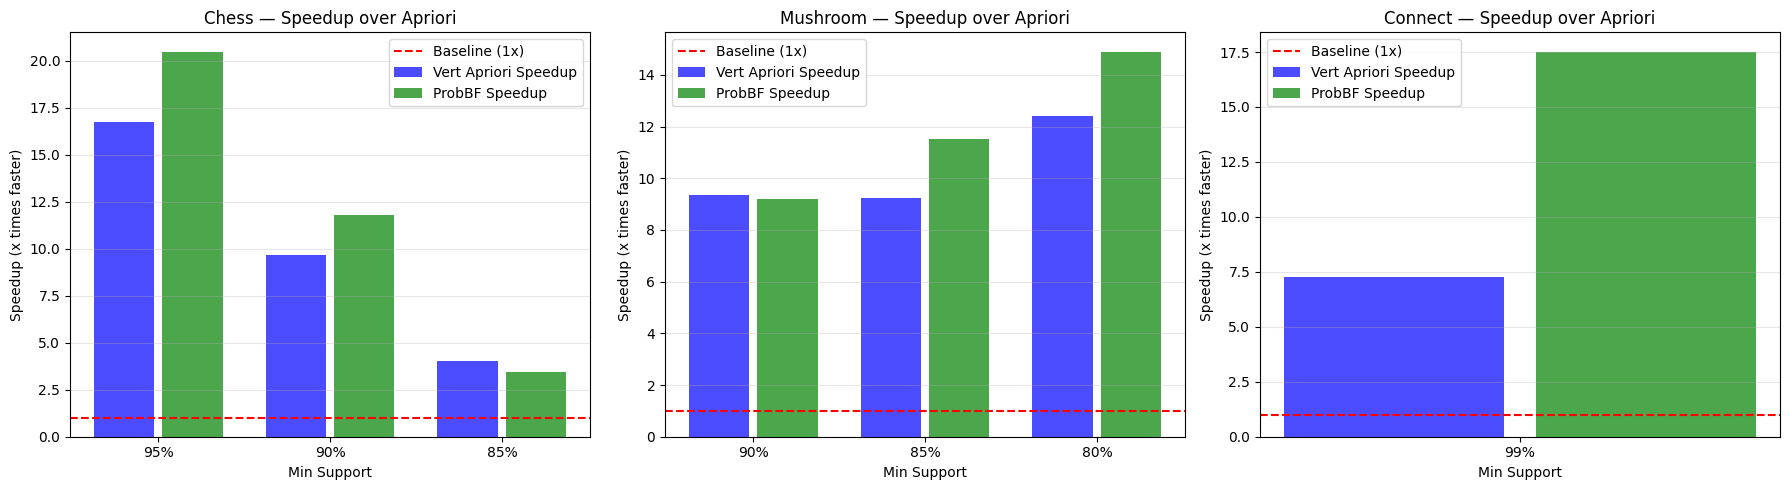

Saved: speedup_comparison.png


In [45]:
fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df['Dataset'] == ds].copy()
    x = [f"{int(s*100)}%" for s in sub['min_sup']]
    ax.bar([i - 0.2 for i in range(len(x))], sub['Speedup_Vert'],  width=0.35, label='Vert Apriori Speedup', color='blue', alpha=0.7)
    ax.bar([i + 0.2 for i in range(len(x))], sub['Speedup_ProbBF'], width=0.35, label='ProbBF Speedup', color='green', alpha=0.7)
    ax.axhline(y=1, color='red', linestyle='--', label='Baseline (1x)')
    ax.set_xticks(range(len(x)))
    ax.set_xticklabels(x)
    ax.set_title(f'{ds} — Speedup over Apriori')
    ax.set_xlabel('Min Support')
    ax.set_ylabel('Speedup (x times faster)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('speedup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: speedup_comparison.png')

## Cell 14: Export Results to CSV

In [46]:
df.to_csv('fim_results.csv', index=False)
print('Results saved to fim_results.csv')
print('\nFinal Summary:')
print(df[['Dataset','min_sup','Apriori_time','VertApriori_time','ProbBF_time',
          'Speedup_Vert','Speedup_ProbBF']].to_string(index=False))

Results saved to fim_results.csv

Final Summary:
 Dataset  min_sup  Apriori_time  VertApriori_time  ProbBF_time  Speedup_Vert  Speedup_ProbBF
   Chess     0.95        0.7954            0.0475       0.0388         16.75           20.50
   Chess     0.90        6.7106            0.6937       0.5698          9.67           11.78
   Chess     0.85       33.5057            8.2837       9.8002          4.04            3.42
Mushroom     0.90        0.3731            0.0399       0.0405          9.35            9.21
Mushroom     0.85        0.4430            0.0479       0.0385          9.25           11.51
Mushroom     0.80        0.5857            0.0472       0.0393         12.41           14.90
 Connect     0.99      103.9162           14.2935       5.9326          7.27           17.52


## Cell 15: Quick Sanity Check on Small Toy Data

In [47]:
# Toy dataset from Table 1 of the ProbBF paper
toy = [
    frozenset([1,2,4]),      # ABD
    frozenset([1,2,3,6]),    # ABCF
    frozenset([1,2,3,5]),    # ABCE
    frozenset([1,3,4,6]),    # ACDF
    frozenset([1,2,3,5,6]),  # ABCEF
    frozenset([1,3,4,5]),    # ACDE
    frozenset([1,2,3,4]),    # ABCD
    frozenset([2,4,5]),      # BDE
    frozenset([1,2,3,5]),    # ABCE
    frozenset([1,2,4,6]),    # ABDF
]

print('=== TOY DATASET SANITY CHECK (min_sup=20%) ===')

(fi_a, cands_a), t_a, _ = measure(apriori, toy, 0.2)
print(f'Apriori:      {len(fi_a)} frequent itemsets, {cands_a} candidates')

(fi_v, cands_v), t_v, _ = measure(apriori_vertical, toy, 0.2)
print(f'Vert Apriori: {len(fi_v)} frequent itemsets, {cands_v} candidates')

fi_p, t_p, _ = measure(probBF, toy, 0.2)
print(f'ProbBF:       {len(fi_p)} frequent itemsets (approximate)')

print('\nAll 3 algorithms ran successfully on toy data!')

=== TOY DATASET SANITY CHECK (min_sup=20%) ===
Apriori:      32 frequent itemsets, 39 candidates
Vert Apriori: 32 frequent itemsets, 100 candidates
ProbBF:       32 frequent itemsets (approximate)

All 3 algorithms ran successfully on toy data!
